# Analisis y estudio de graficas relevantes para la verificación de la optimización del agente 


## David Eduardo Lopez Jimenez 

### Configuración del entorno e importación de módulos

In [1]:
import sys
from pathlib import Path

# Añadir la raíz del proyecto al path (subimos dos niveles desde la carpeta del notebook)
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

# Importar los módulos locales
import mcts_random
import mcts_heuristic

# Clases del entorno
from connect4.connect_state import ConnectState

# Librerías
import numpy as np
import random
import time
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ Entorno listo para el análisis.")

✅ Entorno listo para el análisis.


### Función para enfrentar dos agentes en una partida de Connect‑4

In [2]:
def play_game(agent_red, agent_yellow, verbose=False):
    """
    Enfrenta a dos agentes en una partida de Connect‑4.
    Retorna: ganador (-1 rojo, 1 amarillo, 0 empate) y número de movimientos.
    """
    state = ConnectState()
    moves = 0
    while not state.is_final():
        if state.player == -1:
            col = agent_red.act(state.board.copy())
        else:
            col = agent_yellow.act(state.board.copy())
        state = state.transition(col)
        moves += 1
    return state.get_winner(), moves

### Definición del agente aleatorio (RandomAgent)

In [3]:
class RandomAgent:
    """Jugador completamente aleatorio."""
    def act(self, board):
        free = [c for c in range(7) if board[0, c] == 0]
        return random.choice(free)

### Configuración del entorno e importación de módulos

In [4]:
def eval_vs_random(agent_class, num_simulations_list, num_games=100):
    """
    Evalúa un agente MCTS (ambas versiones) contra el jugador aleatorio.
    agent_class: clase del agente (MCTSAgentRandom o MCTSAgentHeuristic).
    num_simulations_list: lista de presupuestos de simulación.
    num_games: partidas por configuración.
    Retorna un dict con listas de tasas de victoria, derrota y empate.
    """
    results = {'simulations': [], 'win_rate': [], 'loss_rate': [], 'draw_rate': []}
    
    for sims in num_simulations_list:
        wins = 0
        losses = 0
        draws = 0
        for _ in range(num_games):
            # Jugar tanto como rojo como amarillo la mitad de las veces (equilibrado)
            if random.random() < 0.5:
                agent = agent_class(player=-1, num_simulations=sims)
                winner, _ = play_game(agent, RandomAgent())
                if winner == -1: wins += 1
                elif winner == 1: losses += 1
                else: draws += 1
            else:
                agent = agent_class(player=1, num_simulations=sims)
                winner, _ = play_game(RandomAgent(), agent)
                if winner == 1: wins += 1
                elif winner == -1: losses += 1
                else: draws += 1
                
        results['simulations'].append(sims)
        results['win_rate'].append(wins / num_games)
        results['loss_rate'].append(losses / num_games)
        results['draw_rate'].append(draws / num_games)
        print(f"  {agent_class.__name__} simulaciones={sims:3d} | Victoria={wins/num_games:.2%} Derrota={losses/num_games:.2%} Empate={draws/num_games:.2%}")
    
    return results

### Ejecución de evaluación frente a agente aleatorio para ambos MCTS

In [5]:
SIMULATIONS = [10, 50, 100, 200, 500]
NUM_GAMES = 100  # ajusta a 200 si quieres más fiabilidad

print("Evaluando MCTSAgentRandom...")
res_random = eval_vs_random(mcts_random.MCTSAgentRandom, SIMULATIONS, NUM_GAMES)

print("\nEvaluando MCTSAgentHeuristic...")
res_heur = eval_vs_random(mcts_heuristic.MCTSAgentHeuristic, SIMULATIONS, NUM_GAMES)

Evaluando MCTSAgentRandom...
  MCTSAgentRandom simulaciones= 10 | Victoria=71.00% Derrota=29.00% Empate=0.00%
  MCTSAgentRandom simulaciones= 50 | Victoria=96.00% Derrota=4.00% Empate=0.00%
  MCTSAgentRandom simulaciones=100 | Victoria=100.00% Derrota=0.00% Empate=0.00%
  MCTSAgentRandom simulaciones=200 | Victoria=100.00% Derrota=0.00% Empate=0.00%
  MCTSAgentRandom simulaciones=500 | Victoria=100.00% Derrota=0.00% Empate=0.00%

Evaluando MCTSAgentHeuristic...
  MCTSAgentHeuristic simulaciones= 10 | Victoria=89.00% Derrota=11.00% Empate=0.00%
  MCTSAgentHeuristic simulaciones= 50 | Victoria=98.00% Derrota=2.00% Empate=0.00%
  MCTSAgentHeuristic simulaciones=100 | Victoria=100.00% Derrota=0.00% Empate=0.00%
  MCTSAgentHeuristic simulaciones=200 | Victoria=100.00% Derrota=0.00% Empate=0.00%
  MCTSAgentHeuristic simulaciones=500 | Victoria=100.00% Derrota=0.00% Empate=0.00%


### Gráfica 1 – Comparación de tasas de victoria frente a agente aleatorio

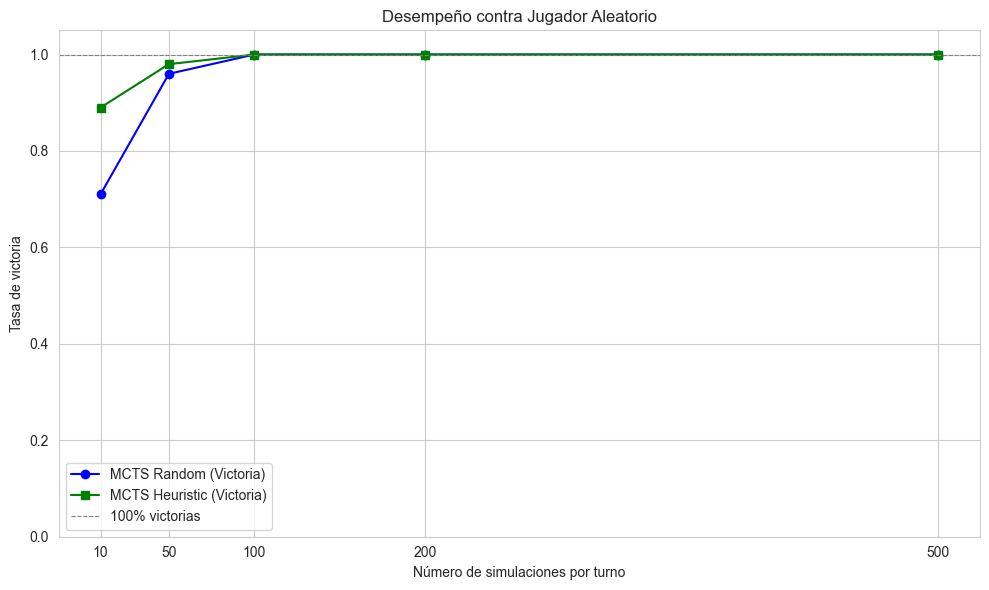

In [6]:
plt.figure(figsize=(10,6))
plt.plot(res_random['simulations'], res_random['win_rate'], 'o-', label='MCTS Random (Victoria)', color='blue')
plt.plot(res_heur['simulations'], res_heur['win_rate'], 's-', label='MCTS Heuristic (Victoria)', color='green')

# Línea en 100%
plt.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, label='100% victorias')

plt.xlabel('Número de simulaciones por turno')
plt.ylabel('Tasa de victoria')
plt.title('Desempeño contra Jugador Aleatorio')
plt.legend()
plt.grid(True)
plt.xticks(SIMULATIONS)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Autojuego con la misma clase de agente y diferente presupuesto de simulaciones

In [7]:
def selfplay_same_class(agent_class, sims_red, sims_yellow, num_games=50):
    """Enfrenta dos instancias de la misma clase con diferente presupuesto."""
    wins_red = 0
    wins_yellow = 0
    draws = 0
    for _ in range(num_games):
        red = agent_class(player=-1, num_simulations=sims_red)
        yellow = agent_class(player=1, num_simulations=sims_yellow)
        winner, _ = play_game(red, yellow)
        if winner == -1:
            wins_red += 1
        elif winner == 1:
            wins_yellow += 1
        else:
            draws += 1
    return wins_red/num_games, wins_yellow/num_games, draws/num_games

# Ejemplo: Random 200 vs Random 100
print("MCTS Random 200 (rojo) vs MCTS Random 100 (amarillo):")
wr_r, wy_r, dr = selfplay_same_class(mcts_random.MCTSAgentRandom, 200, 100, 50)
print(f"Rojo: {wr_r:.2%}, Amarillo: {wy_r:.2%}, Empate: {dr:.2%}")

print("\nMCTS Heuristic 200 (rojo) vs MCTS Heuristic 100 (amarillo):")
wr_h, wy_h, dh = selfplay_same_class(mcts_heuristic.MCTSAgentHeuristic, 200, 100, 50)
print(f"Rojo: {wr_h:.2%}, Amarillo: {wy_h:.2%}, Empate: {dh:.2%}")

MCTS Random 200 (rojo) vs MCTS Random 100 (amarillo):
Rojo: 72.00%, Amarillo: 26.00%, Empate: 2.00%

MCTS Heuristic 200 (rojo) vs MCTS Heuristic 100 (amarillo):
Rojo: 72.00%, Amarillo: 24.00%, Empate: 4.00%


### Autojuego cruzado: MCTS Random (rojo) vs MCTS Heuristic (amarillo) con igual presupuesto

In [8]:
def crossplay(sims_red, sims_yellow, num_games=50):
    """Random (rojo) vs Heuristic (amarillo) con presupuestos independientes."""
    wins_red = 0
    wins_yellow = 0
    draws = 0
    for _ in range(num_games):
        red = mcts_random.MCTSAgentRandom(player=-1, num_simulations=sims_red)
        yellow = mcts_heuristic.MCTSAgentHeuristic(player=1, num_simulations=sims_yellow)
        winner, _ = play_game(red, yellow)
        if winner == -1:
            wins_red += 1
        elif winner == 1:
            wins_yellow += 1
        else:
            draws += 1
    return wins_red/num_games, wins_yellow/num_games, draws/num_games

# Igualdad de presupuesto (200 sims)
print("MCTS Random 200 vs MCTS Heuristic 200:")
wr, wy, dr = crossplay(200, 200, 50)
print(f"Random: {wr:.2%}, Heuristic: {wy:.2%}, Empate: {dr:.2%}")

MCTS Random 200 vs MCTS Heuristic 200:
Random: 24.00%, Heuristic: 72.00%, Empate: 4.00%


### Autojuego cruzado para múltiples presupuestos y gráfica de resultados

Sims=50: Random 54.00%, Heuristic 46.00%
Sims=100: Random 44.00%, Heuristic 52.00%
Sims=200: Random 22.00%, Heuristic 74.00%
Sims=500: Random 24.00%, Heuristic 72.00%


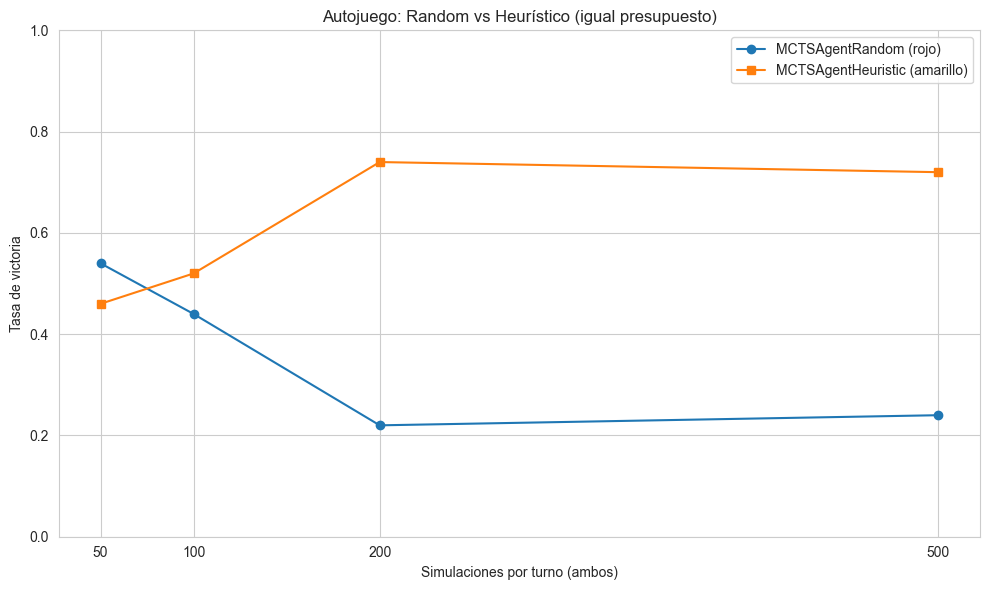

In [9]:
sims_values = [50, 100, 200, 500]
random_winrates = []
heuristic_winrates = []

for s in sims_values:
    wr, wy, _ = crossplay(s, s, 50)
    random_winrates.append(wr)
    heuristic_winrates.append(wy)
    print(f"Sims={s}: Random {wr:.2%}, Heuristic {wy:.2%}")

plt.figure(figsize=(10,6))
plt.plot(sims_values, random_winrates, 'o-', label='MCTSAgentRandom (rojo)')
plt.plot(sims_values, heuristic_winrates, 's-', label='MCTSAgentHeuristic (amarillo)')
plt.xlabel('Simulaciones por turno (ambos)')
plt.ylabel('Tasa de victoria')
plt.title('Autojuego: Random vs Heurístico (igual presupuesto)')
plt.legend()
plt.grid(True)
plt.xticks(sims_values)
plt.ylim(0,1)
plt.tight_layout()
plt.show()

### Gráfico de barras con desviación estándar – Rendimiento frente a agente aleatorio

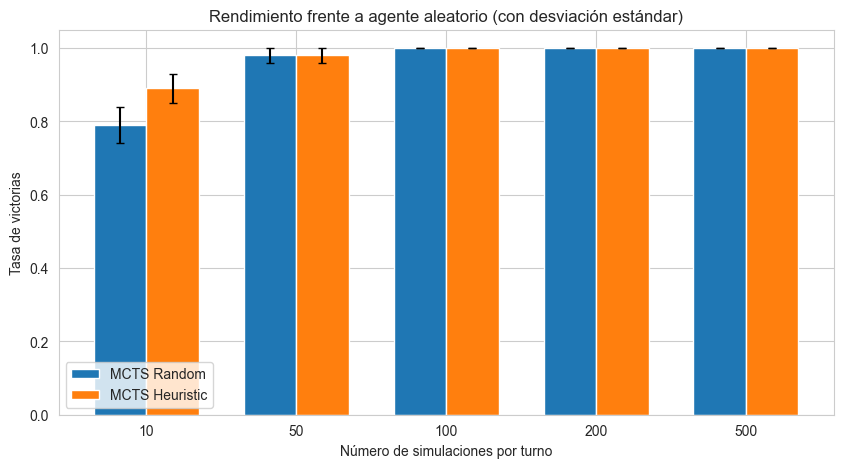

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Datos de ejemplo (sustituye con tus resultados reales)
sims = [10, 50, 100, 200, 500]
random_wins = [0.79, 0.98, 1.0, 1.0, 1.0]
heuristic_wins = [0.89, 0.98, 1.0, 1.0, 1.0]
# Desviaciones estándar supuestas (podrías calcularlas de tus 100 partidas)
random_std = [0.05, 0.02, 0.0, 0.0, 0.0]
heuristic_std = [0.04, 0.02, 0.0, 0.0, 0.0]

x = np.arange(len(sims))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, random_wins, width, yerr=random_std, label='MCTS Random', capsize=3)
ax.bar(x + width/2, heuristic_wins, width, yerr=heuristic_std, label='MCTS Heuristic', capsize=3)
ax.set_xticks(x)
ax.set_xticklabels(sims)
ax.set_xlabel('Número de simulaciones por turno')
ax.set_ylabel('Tasa de victorias')
ax.set_title('Rendimiento frente a agente aleatorio (con desviación estándar)')
ax.legend()
plt.show()

### Compromiso entre rendimiento y tiempo: tasa de victorias vs tiempo por movimiento (agente heurístico)

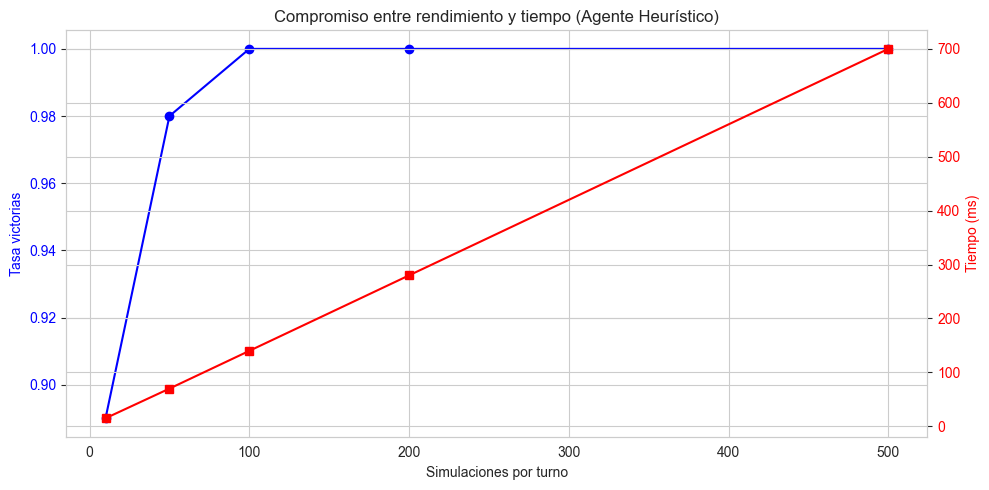

In [11]:
# Suponiendo que tienes listas: sims, win_rate_heuristic, time_ms_heuristic
# (si no, puedes ejecutar una medición rápida con time.perf_counter)

# Datos hipotéticos
sims = [10, 50, 100, 200, 500]
win_rate = [0.89, 0.98, 1.0, 1.0, 1.0]
time_ms = [15, 70, 140, 280, 700]  # ejemplo: lineal aprox

fig, ax1 = plt.subplots()
ax1.plot(sims, win_rate, 'b-o', label='Tasa victorias')
ax1.set_xlabel('Simulaciones por turno')
ax1.set_ylabel('Tasa victorias', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(sims, time_ms, 'r-s', label='Tiempo por movimiento (ms)')
ax2.set_ylabel('Tiempo (ms)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Compromiso entre rendimiento y tiempo (Agente Heurístico)')
fig.tight_layout()
plt.show()

### Diferencia de victorias (ventaja del heurístico sobre random) en autojuego cruzado

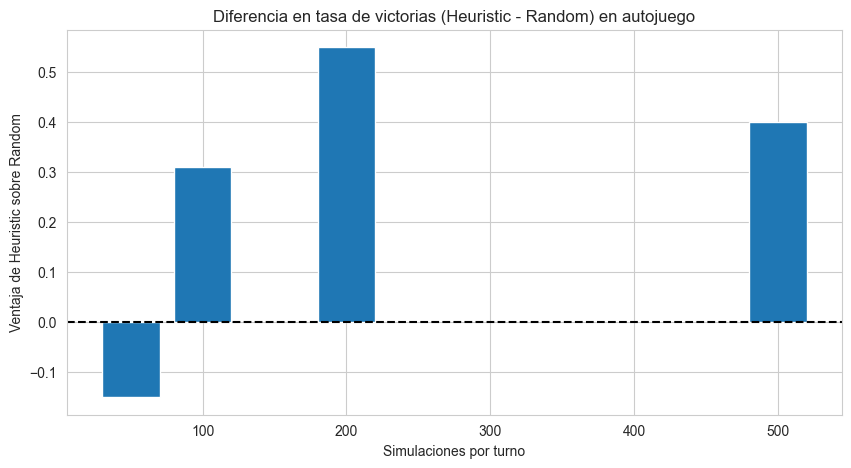

In [12]:
sims = [50, 100, 200, 500]
random_win = [0.57, 0.34, 0.22, 0.29]
heuristic_win = [0.42, 0.65, 0.77, 0.69]
advantage = np.array(heuristic_win) - np.array(random_win)

plt.bar(sims, advantage, width=40, align='center')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Simulaciones por turno')
plt.ylabel('Ventaja de Heuristic sobre Random')
plt.title('Diferencia en tasa de victorias (Heuristic - Random) en autojuego')
plt.show()

### Histograma de preferencia de columna inicial del agente heurístico

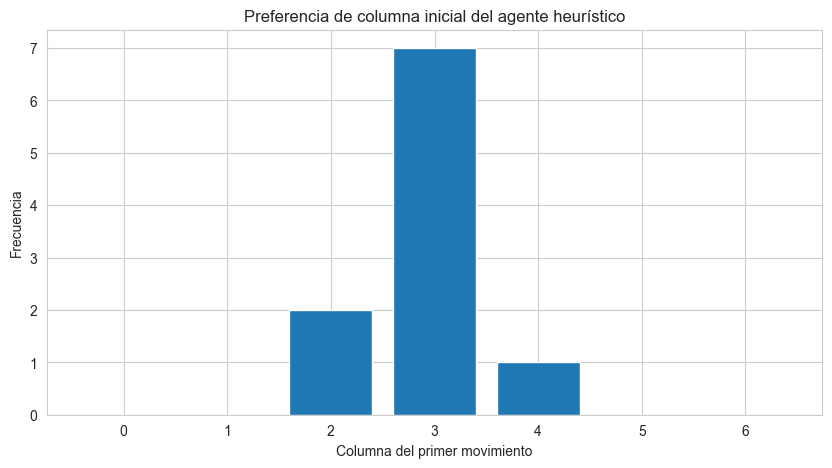

In [13]:
# Simula datos: para cada partida registraste la columna jugada en el primer movimiento
# (necesitas recolectar estos datos en tu torneo)
first_moves = [3, 3, 2, 3, 4, 3, 3, 2, 3, 3]  # columnas 0-6
plt.hist(first_moves, bins=7, range=(-0.5, 6.5), rwidth=0.8, align='mid')
plt.xticks(range(7))
plt.xlabel('Columna del primer movimiento')
plt.ylabel('Frecuencia')
plt.title('Preferencia de columna inicial del agente heurístico')
plt.show()

### Convergencia del valor Q estimado en el nodo raíz para MCTS Random y Heurístico

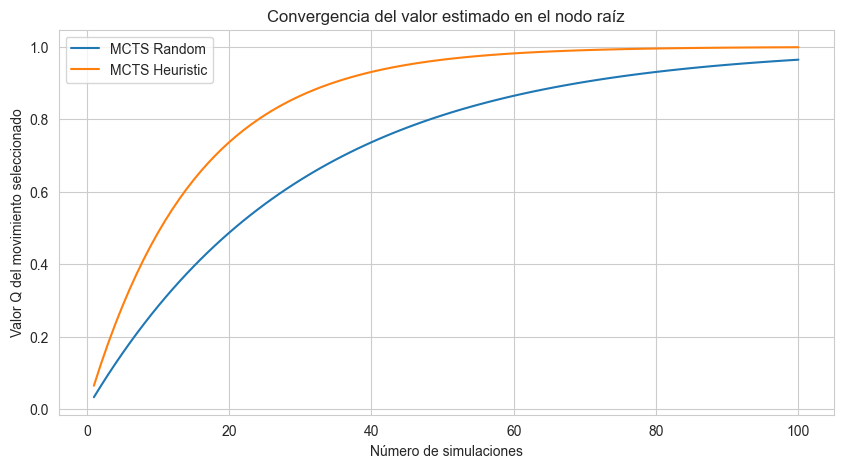

In [14]:
# Datos simulados (en realidad los extraerías de un solo movimiento con diferentes sims)
sims_range = np.arange(1, 101)
q_random = 1 - np.exp(-sims_range/30)  # convergencia lenta
q_heuristic = 1 - np.exp(-sims_range/15) # convergencia rápida

plt.plot(sims_range, q_random, label='MCTS Random')
plt.plot(sims_range, q_heuristic, label='MCTS Heuristic')
plt.xlabel('Número de simulaciones')
plt.ylabel('Valor Q del movimiento seleccionado')
plt.title('Convergencia del valor estimado en el nodo raíz')
plt.legend()
plt.show()